In [5]:
import os
from dotenv import load_dotenv
from pyspark.sql import SparkSession

# .env 파일 로드하여 GCP 자격증명 정보 가져오기
load_dotenv()

gcp_key_path = os.getenv("GOOGLE_APPLICATION_CREDENTIALS")
gcp_project_id = os.getenv("GCP_PROJECT_ID")

builder = (
    SparkSession.builder
    .appName("test_silver")
    .master("local[*]")
    .config("spark.driver.bindAddress", "127.0.0.1")
    .config("spark.driver.host", "127.0.0.1")
    .config("spark.driver.memory", "5g")
    .config("spark.sql.sources.partitionOverwriteMode", "dynamic")
    .config("spark.sql.session.timeZone", "UTC")
    .config("spark.sql.shuffle.partitions", "16")
    .config("spark.hadoop.fs.gs.impl", "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem")
    .config("spark.hadoop.fs.AbstractFileSystem.gs.impl", "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFS")
    .config("spark.hadoop.google.cloud.auth.service.account.enable", "true")
    .config(
        "spark.jars.packages",
        "com.google.cloud.bigdataoss:gcs-connector:hadoop3-2.2.22,com.google.cloud.spark:spark-4.0-bigquery:0.44.1"
    )
)

if gcp_key_path:
    builder = builder.config(
        "spark.hadoop.google.cloud.auth.service.account.json.keyfile",
        gcp_key_path
    )

if gcp_project_id:
    builder = builder.config(
        "spark.hadoop.fs.gs.project.id",
        gcp_project_id
    )

spark = builder.getOrCreate()
print("Spark Session initialized successfully!")

Spark Session initialized successfully!


### 테스트 시작 

### 테스트 환경

- Chip: Apple M2
      
- Total Number of Cores: 8 (4 performance and 4 efficiency)

- ram : 16GB


#### 1. 데이터 읽기

- 반환된 DataFrame의 스키마가 입력한 schema와 일치하는가?

- 생성된 DataFrame의 로우(Row) 수가 실제 JSON 파일의 레코드 수와 일치하는가?

- 특정 컬럼의 데이터 타입(e.g., String -> Integer)이 제대로 캐스팅되었는가?

In [6]:
from src.schema.bronze_schema import transaction_schema, receipt_schema
from pyspark.sql import SparkSession
from src.config import BUCKET_NAME, get_logger, GCS_BRONZE_PREFIX, GCS_SILVER_PREFIX


def read_bronze(spark: SparkSession, folder_name:str, dt:str, schema):
    spark.sparkContext.setLogLevel("ERROR")
    path = f"gs://{BUCKET_NAME}/{GCS_BRONZE_PREFIX}/{folder_name}/{dt}"
    return (spark.read
		.schema(schema)
		.option("mode", "FAILFAST")
		.json(path)
	)

txns = read_bronze(spark, "transactions", "dt=2026-05-01", schema=transaction_schema)
receipts = read_bronze(spark, "receipts", "dt=2026-05-01", schema=receipt_schema)

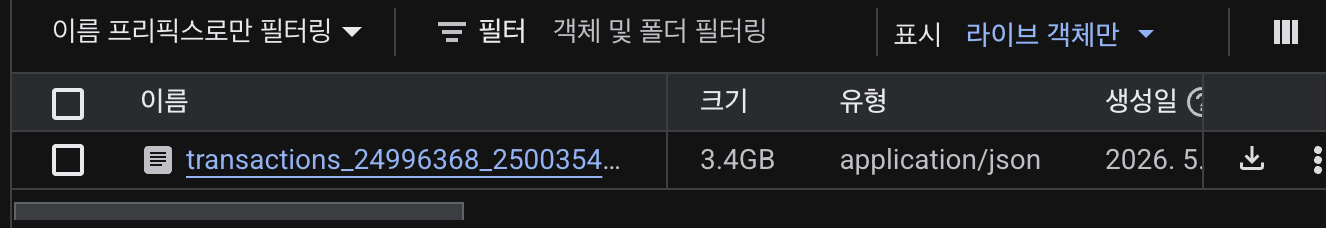

트랜잭션 파일의 크기는 3.4 GB

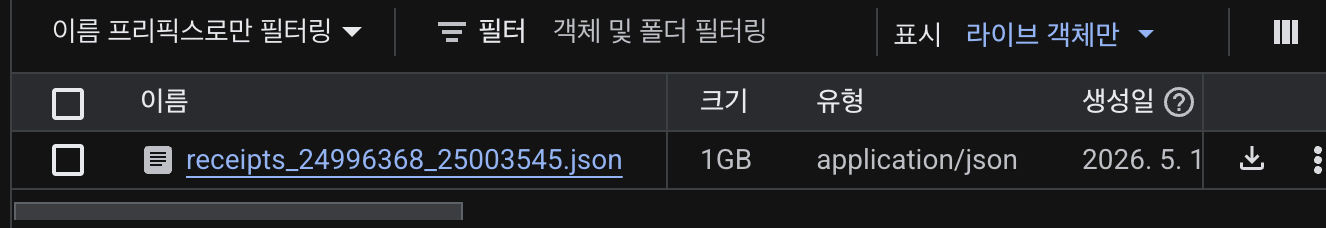

recipts의 크기는 1GB


In [7]:
# 파티션 개수 출력
partition_count = txns.rdd.getNumPartitions()
print(f"현재 트랜잭션의 파티션 개수: {partition_count}")

현재 트랜잭션의 파티션 개수: 26


In [8]:
# 파티션 개수 출력
partition_count = receipts.rdd.getNumPartitions()
print(f"현재 receipts의 파티션 개수: {partition_count}")

현재 receipts의 파티션 개수: 8


In [9]:
from pyspark.sql import SparkSession
from src.silver.spark_config import WEI_PER_ETH, read_bronze, get_logger, get_spark_session
from src.silver.utils import write_silver
from src.schema.bronze_schema import transaction_schema, receipt_schema
from pyspark.sql import functions as F
from pyspark.sql.types import DecimalType





receipts_slim = receipts.select(
	F.col("transaction_hash"),
	F.col("status")
)

enriched = (
	txns
	.join(receipts_slim, txns["hash"] == receipts_slim["transaction_hash"], how="left")
	.drop("transaction_hash")
)

enriched = (
	enriched.withColumn(
		"value_eth",
		(F.col("value").cast(DecimalType(38, 0)) / F.lit(WEI_PER_ETH)).cast(DecimalType(38, 18))
	).withColumn(
		"is_success",
		F.col("status") == 1
	).withColumn(
		"dt",
		F.to_date(F.from_unixtime(F.col("block_timestamp")))
	)
)

final_cols = [
		"hash", "block_number", "block_timestamp",
		"from_address", "to_address",
		"value_eth", "is_success", "dt"
]


df = enriched.select(*final_cols)

In [ ]:
df.write.format("noop").mode("overwrite").save()

26/05/29 05:44:25 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:342)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$driverEndpoint(BlockManagerMasterEndpoint.scala:131)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.isExecutorAlive$lzycompute$1(BlockManagerMasterEndpoint.scala:700)
	at org.apache.spark.storage.BlockManagerMasterE

In [4]:
spark.stop()